In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tqdm import tqdm

from nystroem_ksd.ksd import get_sns_conf

In [2]:
plt.rcParams.update({
    'text.latex.preamble': r'\usepackage{amsfonts}\usepackage{bm}'
})

In [3]:
d2 = pd.read_csv("../results/directional-d2.csv", index_col=0)
d3unif = pd.read_csv("../results/directional-d3-uniform.csv", index_col=0)
d3vMF = pd.read_csv("../results/directional-d3-vMF.csv", index_col=0)

In [4]:
algorithms = ["N-KSD", "KSD", "Rayleigh"]
labels = algorithms
sns_conf = get_sns_conf(algorithms=algorithms)

d2 = d2.sort_values("test")
d3unif = d3unif.sort_values("test")
d3vMF = d3vMF.sort_values("test")

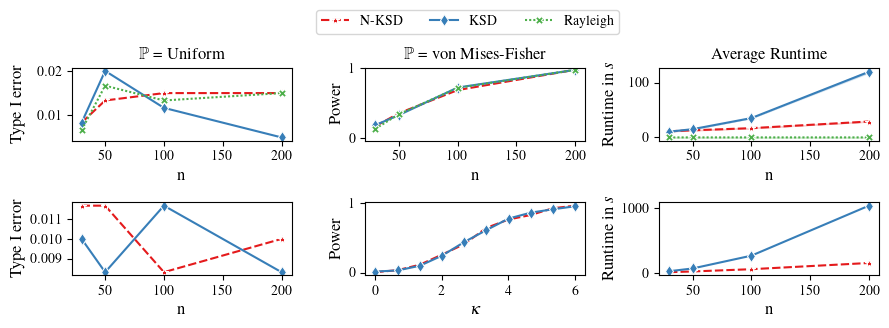

In [5]:
fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2,3,figsize=(9,3))
sns.lineplot(data=d2[d2["data"] == "Uniform"], x="n", y="rejects", hue="test", ax=ax1, style="test", **sns_conf)
sns.lineplot(data=d2[d2["data"] == "VonMises"], x="n", y="rejects", hue="test", ax=ax2, style="test", **sns_conf)
sns.lineplot(data=d2, x="n", y="time", hue="test", ax=ax3, style="test", **sns_conf)

sns.lineplot(data=d3unif[d3unif["data"] == "Uniform"], x="n", y="rejects", hue="test", ax=ax4, style="test", **sns_conf)
sns.lineplot(data=d3vMF[d3vMF["data"] == "VonMises"], x="kappa", y="rejects", hue="test", ax=ax5, style="test", **sns_conf)
sns.lineplot(data=d3unif, x="n", y="time", hue="test", ax=ax6, style="test", **sns_conf)

Line, Label = ax1.get_legend_handles_labels()
for ax in [ax1,ax2,ax3]:
    ax.get_legend().remove()
    ax.set_xlabel("n")
for ax in [ax4,ax5,ax6]:
    ax.get_legend().remove()
    ax.set_xlabel("n")
ax5.set_xlabel("$\\kappa$")

fig.legend(Line, Label, loc="upper center", bbox_to_anchor=(0.525, 1.1), ncol=3)
ax2.set_ylim((np.float64(-0.04266666666666667), np.float64(1.006)))
ax1.set_ylabel("Type I error")
ax4.set_ylabel("Type I error")
ax2.set_ylabel("Power")
ax5.set_ylabel("Power")
ax3.set_ylabel("Runtime in $s$")
ax6.set_ylabel("Runtime in $s$")

ax1.set_title("$\\mathbb {P}$ = Uniform")
ax2.set_title("$\\mathbb {P}$ = von Mises-Fisher")
ax3.set_title("Average Runtime")

fig.align_ylabels()
plt.tight_layout()
#plt.savefig("../../figures/directional-ksd.pdf", bbox_inches=None, pad_inches=0)
plt.show()

In [6]:
d2


,n,data,test,rejects,time
0,50,VonMises,KSD,0.33,2.850383
0,200,Uniform,KSD,0.01,20.539018
0,100,VonMises,KSD,0.81,6.608052
0,100,Uniform,KSD,0.03,6.228400
0,50,Uniform,KSD,0.01,2.606023
0,200,VonMises,KSD,0.98,31.091336
0,30,VonMises,KSD,0.18,1.871727
0,30,Uniform,KSD,0.02,1.922354
0,50,Uniform,N-KSD,0.03,2.199688
0,30,VonMises,N-KSD,0.20,2.167592
